In [1]:
import time
import random
import os
import math
import pickle

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from scipy.spatial import Delaunay

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data.sampler import SubsetRandomSampler

In [53]:
# UTILS
def read_custom_csv(file_path):
    """ Read a csv file and store in a dictionary each category"""

    data = {}
    current_title = None

    categories = ["EC-cones", "IC-cones", "F-cones", "EC-points", "IC-points","MC-points", "True-MidPoints"]

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip() # Remove non desired white spaces
            if line in categories:
                current_title = line
                data[current_title] = []
            else:
                x, y = map(float, line.split(',')) # Convert to float and separate by comma
                data[current_title].append((x, y))

    return data

# Split car positions from cones points
def get_car_postions(data_publisher):
    """ Get car positions from the data_publicher df, store them in a new df 
    and remove them from data_publisher.
    Input:
        data_publisher: Input df. Have car positions as first row of each iteration
    Output:
        data_publisher: Input df without car positions
        car_positions: Df with car position per iteration
    """
    # Dataframe to store car position per iteration
    car_position = data_publisher.head(1)

    # Track the last seen iteration value
    last_iteration = 0

    # Iterate over rows in the DataFrame
    for index, row in data_publisher.iterrows():
        current_iteration = int(row['iteration_index'])
        
        # If the iteration value changes
        if current_iteration != last_iteration:
            # Put row in dataframe friendly format
            df_row = pd.DataFrame({'iteration_index':[current_iteration], 'x':[row['x']], 'y':[row['y']]})
            # Add row to dataframe
            car_position = pd.concat([car_position,df_row], ignore_index=True)
            # Drop the row from the original DataFrame
            data_publisher.drop(index, inplace=True)
        
        # Update the last seen iteration value
        last_iteration = current_iteration
    
    # Remove first car position
    data_publisher.drop(index=0, inplace=True)

    return data_publisher, car_position

def middle_points(triangulation):
    """ Given triangulations of points, return the middle points.
        Input: 
            - triangulation: Indices of points that form each triangle
        Output::
            - middle points: Points that indicate the true path
    """
    
    edges = set()
    for simplex in triangulation.simplices:
        for i in range(3):
            edge = tuple(sorted([simplex[i], simplex[(i + 1) % 3]]))
            edges.add(edge)
    middle_points = [(triangulation.points[edge[0]] + triangulation.points[edge[1]]) / 2 for edge in edges]
    return middle_points

def euclidean_distance(p1, p2):
    """ Computes the euclidean distance between two points x,y
        Input:
            - p1,p2: 2D points
    """
    
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def preprocess(data_publisher):

    # Extract the position of the car
    data_publisher, car_position = get_car_postions(data_publisher)
    # Fuse columns x,y together
    data_publisher['point'] = list(zip(data_publisher['x'], data_publisher['y']))
    car_position['point'] = list(zip(car_position['x'], car_position['y']))
    # Group points per iteration in a list <iteration>:[(x1,y1), (x2,y2), ...]
    dp_grouped = data_publisher.groupby('iteration_index')[['point']].agg(list)
    dp_grouped.reset_index(inplace=True)

    # Compute all triangulations we can get from points of iteration
    dp_grouped['triangulation'] = dp_grouped['point'].apply(lambda points: Delaunay(points))

    # Get the midpoints we can get from the points of each iteration
    dp_grouped['middle_points'] = dp_grouped['triangulation'].apply(middle_points)

    return dp_grouped, car_position

def create_seq(dp_grouped, data_GT, car_position, error_margin = 0.001):

    input_sequence = []
    output_sequence = []

    # Iterate over each iteration (time stamp)
    for i in range(len(dp_grouped)):
        # Get data for the current iteration
        it = dp_grouped[dp_grouped['iteration_index']==i]
        car_it = car_position[car_position['iteration_index']==i]
        # List of cones we detect in the i-th iteration
        points = it['point'][i]
        # Car position
        car_point = [car_it['point'][i]]
        # Midpoints originated from triangulation the cones of the i-th iteration
        # Rounding is done because the ground truth midpoints are also rounded to 4 decimal
        all_midPoints = [(round(arr[0],4), round(arr[1],4)) for arr in it['middle_points'][i]]
        # Create a list containing points from allMidpoints that are within the error margin of any point in trueMidpoints
        current_midpoints = [point for point in all_midPoints if any(euclidean_distance(point, true_point) < error_margin for true_point in data_GT['True-MidPoints'])]

        input_sequence.append(torch.tensor(car_point + points, dtype=torch.float32))
        output_sequence.append(torch.tensor(current_midpoints, dtype=torch.float32))
    
    return input_sequence, output_sequence

def plot_points(points, points2=None, points3=None, infL=-25, upL=120):

    # Definir los límites del eje
    plt.xlim(infL, upL)
    plt.ylim(infL, upL)

    x1 = [point[0] for point in points]
    y1 = [point[1] for point in points]
    plt.scatter(x1, y1, label="arg1")

    if points2 is not None:
        x2 = [point[0] for point in points2]
        y2 = [point[1] for point in points2]
        plt.scatter(x2, y2, label="arg2")

        if points3 is not None:
            x3 = [point[0] for point in points3]
            y3 = [point[1] for point in points3]
            plt.scatter(x3, y3,label="arg3")

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Bird\'s Eye View')
    plt.legend()
    #plt.gca().invert_yaxis()  # Invert y-axis to match typical BEV representation
    plt.show()

In [3]:
# Specify the path to CSV files within the subfolder
folder_path_gt = './tilke_circuits_GT/'
folder_path_it = './tilke_database_2/'
# Get and store all files (either the .csv of GT or it have the same names)
file_list = os.listdir(folder_path_gt)
csv_files = [file for file in file_list if file.endswith(".csv")]

**1. CREATE PAIRS INPUT_SEQ-OUTPUT_SEQ**

In [ ]:
input_sequence = []
output_sequence = []
# Keep track of progress
num_circuits_to_process = len(csv_files)
num_circuits_processed = 0

for csv_file in csv_files:
    csv_path_gt = folder_path_gt+csv_file
    csv_path_it = folder_path_it+csv_file

    data_GT = read_custom_csv(csv_path_gt)
    data_publisher = pd.read_csv(csv_path_it)

    try:
        dp_grouped, car_position = preprocess(data_publisher=data_publisher)
        new_input, new_output = create_seq(dp_grouped, data_GT, car_position)
        input_sequence += new_input
        output_sequence += new_output
    except:
        print("ERROR al csv: ", csv_file, " is not going to be processed")
        pass

    # Keep track of progress
    num_circuits_processed += 1
    print("Progress : ", 100 * num_circuits_processed/ num_circuits_to_process)


# Save
with open('data.pkl', 'wb') as f:
    pickle.dump([input_sequence, output_sequence], f)

**2.Prepare the DataLoader**

In [2]:
def filter_wrong_tensors(input_sequence, output_sequence):
    """Ensures all tensors have two columns, which refers to coordinates x and y of points.
    Whenever a tensor have different shape means there is an error in the data so we have 
    to delete it.
    """

    inpS = []
    outS = []
    i = 0
    for tensor in output_sequence:
        if tensor.size(-1) != 2:
            #del output_sequence[i]
            #del input_sequence[i]
            print("Deleted ", i)
        else:
            inpS.append(input_sequence[i][0:10])
            outS.append(output_sequence[i][0:10])
        i+=1
    
    # Filter last 3 for batch purposes
    #del output_sequence[i-1]
    #del output_sequence[i-2]
    #del output_sequence[i-3]

    #del input_sequence[i-1]
    #del input_sequence[i-2]
    #del input_sequence[i-3]
    #print("Deleted ", i-1)
    #print("Deleted ", i-2)
    #print("Deleted ", i-3)
    
    return inpS, outS

In [3]:
class CustomDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        input_seq = self.inputs[idx]
        target_seq = self.targets[idx]
        return input_seq, target_seq

In [27]:
params = {
    'batch_size':32,
    'hidden_size':128,
    'lr':0.01,
    'n_epochs':20,
    'criterion': nn.HuberLoss()    
}

In [6]:
# Load
with open('data.pkl', 'rb') as f:
    input_sequence, output_sequence = pickle.load(f)

# input_sequence dim: [#seqs, *, 2] = [11683, *, 2]
# output_sequence dim: [#seqs, *, 2] = [11683, *, 2]
input_sequence, output_sequence = filter_wrong_tensors(input_sequence, output_sequence)
# padded_input_seq dim: [#seqs, T_input, 2] = [11683, 56, 2]
padded_input_seq = pad_sequence(input_sequence, batch_first=True, padding_value=0.0)
# padded_target_seq dim: [#seqs, T_target, 2] = [11683, 38, 2]
padded_target_seq = pad_sequence(output_sequence, batch_first=True, padding_value=0.0)

# Create dataset
# Each dataset[idx] = [input_seq: tensor 56x2; target_seq: tensor 38x2]
dataset = CustomDataset(padded_input_seq, padded_target_seq)

# Params
validation_split = .2
shuffle = True   # Shuffle the data during training
random_seed= 42

# Creating data indices for training and validation splits:
dataset_size = len(dataset)
indices = list(range(dataset_size))
split = int(np.floor(validation_split * dataset_size))
if shuffle :
    np.random.seed(random_seed)
    np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]

# Creating PT data samplers and loaders:
train_sampler = SubsetRandomSampler(train_indices)
valid_sampler = SubsetRandomSampler(val_indices)

# Create DataLoader
trainLoader = DataLoader(dataset, batch_size=params["batch_size"], sampler=train_sampler)
validLoader = DataLoader(dataset, batch_size=params["batch_size"], sampler=valid_sampler)

Deleted  140


In [7]:
for i, batch in enumerate(trainLoader):
    print("Input size [Batch,SeqLength,Features]: ",  batch[0].shape)
    print("Ouptut size [Batch,SeqLength,Features]: ", batch[1].shape)
    input_size = (batch[0].shape)[2]
    output_size = (batch[1].shape)[2]
    print("Input size is: ", input_size)
    print("Output size is: ", output_size)
    break

Input size [Batch,SeqLength,Features]:  torch.Size([32, 10, 2])
Ouptut size [Batch,SeqLength,Features]:  torch.Size([32, 10, 2])
Input size is:  2
Output size is:  2


**3. Create the model**

In [16]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)


def plotLoss(train_loss, n_epochs):
    # Retrieve each dictionary's values
    # train_values = train_loss.values()
    train_values = train_loss
    # val_values = val_loss.values()
    
    # Generate a sequence of integers to represent the epoch numbers
    epochs = range(1, n_epochs+1)
    
    # Plot and label the training and validation loss values
    plt.plot(epochs, train_values, label='Training Loss')
    #plt.plot(epochs, val_values, label='Validation Loss')
    
    # Add in a title and axes labels
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    
    # Set the tick locations
    plt.xticks(range(0, 21, 2))
    
    #Display the plot
    plt.legend(loc='best')
    plt.show()

In [17]:
device =  torch.device('cpu')
MAX_LENGTH=10

In [18]:
class EncoderSimple(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(EncoderSimple, self).__init__()
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)

    def forward(self, x):
        output, hidden_state = self.gru(x)
        return output, hidden_state


class DecoderSimple(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderSimple, self).__init__()
        self.output_size = output_size
        self.gru = nn.GRU(output_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.zeros([batch_size,MAX_LENGTH,self.output_size], dtype=torch.float32, device=device) # (32, 2)
        decoder_hidden = encoder_hidden # (1, batch_size, hidden_size) 

        output, decoder_hidden  = self.gru(decoder_input, decoder_hidden) # decoder_hidden size: (1, batch_size, hidden_size)
        decoder_output = self.out(output) # (batch_size, T, output_size)
        
        return decoder_output, decoder_hidden, None # We return `None` for consistency in the training loop


class Seq2SeqSimple(nn.Module):
    def __init__(self, input_size,hidden_size,output_size):
        super(Seq2SeqSimple, self).__init__()
        
        self.encoder = EncoderSimple(input_size, hidden_size)
        self.decoder = DecoderSimple(hidden_size, output_size)

    def forward(self, input_tensor):
        
        encoder_outputs, encoder_hidden = self.encoder(input_tensor)
        decoder_outputs, _, _ = self.decoder(encoder_outputs, encoder_hidden)

        return decoder_outputs


In [19]:
encoder_simple = EncoderSimple(input_size, params["hidden_size"]).to(device)
decoder_simple = DecoderSimple(params["hidden_size"], output_size).to(device)

In [22]:
def train_simple(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0

    for data in dataloader:
        input_tensor, target_tensor = data
        input_tensor.to(device)
        target_tensor.to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden)

        loss = criterion(decoder_outputs,target_tensor)
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def trainSimple(dataloader, encoder, decoder, n_epochs=1, learning_rate=0.01, criterion= nn.HuberLoss()):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every epoch
    plot_loss_total = 0  # Reset every epoch

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    
    print("Start training")
    for epoch in range(1,n_epochs+1):        
        loss = train_simple(dataloader, encoder,decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        print_loss_avg = print_loss_total
        print('Time: %s,  Epoch:%d, Loss avg:%.4f' % (timeSince(start, epoch / n_epochs),
                                     epoch, print_loss_avg))
        print_loss_total = 0

        plot_loss_avg = plot_loss_total
        plot_losses.append(plot_loss_avg)
        plot_loss_total = 0

    plotLoss(plot_losses, n_epochs)

Start training
Time: 0m 6s (- 1m 0s),  Epoch:1, Loss avg:39.4923
Time: 0m 11s (- 0m 44s),  Epoch:2, Loss avg:22.6875
Time: 0m 15s (- 0m 36s),  Epoch:3, Loss avg:15.2102
Time: 0m 20s (- 0m 30s),  Epoch:4, Loss avg:11.7930
Time: 0m 24s (- 0m 24s),  Epoch:5, Loss avg:10.3600
Time: 0m 29s (- 0m 19s),  Epoch:6, Loss avg:9.9006
Time: 0m 33s (- 0m 14s),  Epoch:7, Loss avg:9.6199
Time: 0m 38s (- 0m 9s),  Epoch:8, Loss avg:9.1221
Time: 0m 42s (- 0m 4s),  Epoch:9, Loss avg:9.3433
Time: 0m 47s (- 0m 0s),  Epoch:10, Loss avg:9.1790


<Figure size 640x480 with 0 Axes>

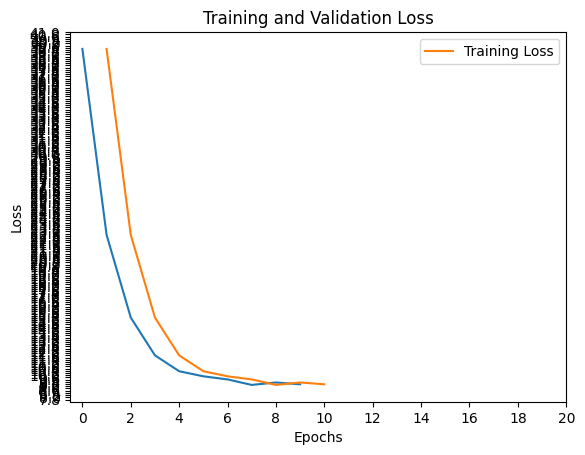

In [21]:
trainSimple(trainLoader, encoder_simple, decoder_simple, n_epochs=params["n_epochs"], learning_rate=params["lr"], criterion= params["criterion"])

In [60]:
for i, batch in enumerate(validLoader):
    input_seq,output_sequence = batch
    print("Batch size is: ", batch[0].shape)
    for j in range (20):
        inp_ex = input_sequence[j]
        out_ex = output_sequence[j]
        with torch.no_grad():
            inp_ex.to(device)
            encoder_outputs, encoder_hidden = encoder_simple(inp_ex)
            output_sequence = decoder_simple(encoder_outputs, encoder_hidden)
        pred = output_sequence.tolist()[0]
        target = out_ex.tolist()
        plot_points(pred, target)
        time.sleep(2)
    break

Batch size is:  torch.Size([32, 10, 2])


RuntimeError: For batched 3-D input, hx should also be 3-D but got 2-D tensor

**4. Train encoder-decoder jointly: end-to-end**

In [31]:
def train_simple_E2E(dataloader,model, optimizer, criterion):
    total_loss = 0

    for data in dataloader:
        input_tensor, target_tensor = data
        input_tensor.to(device)
        target_tensor.to(device)

        optimizer.zero_grad()

        decoder_outputs = model(input_tensor)

        loss = criterion(decoder_outputs,target_tensor)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def trainSimple_E2E(dataloader, model, n_epochs=1, learning_rate=0.01, criterion= nn.HuberLoss()):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every epoch
    plot_loss_total = 0  # Reset every epoch

    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    print("Start training")
    for epoch in range(1,n_epochs+1):        
        loss = train_simple_E2E(dataloader, model, optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        print_loss_avg = print_loss_total
        print('Time: %s,  Epoch:%d, Loss avg:%.4f' % (timeSince(start, epoch / n_epochs),
                                     epoch, print_loss_avg))
        print_loss_total = 0

        plot_loss_avg = plot_loss_total
        plot_losses.append(plot_loss_avg)
        plot_loss_total = 0

    plotLoss(plot_losses, n_epochs)

In [32]:
model = Seq2SeqSimple(input_size, params["hidden_size"], output_size)
model

Seq2SeqSimple(
  (encoder): EncoderSimple(
    (gru): GRU(2, 128, batch_first=True)
  )
  (decoder): DecoderSimple(
    (gru): GRU(2, 128, batch_first=True)
    (out): Linear(in_features=128, out_features=2, bias=True)
  )
)

Start training
Time: 0m 7s (- 2m 21s),  Epoch:1, Loss avg:38.5173
Time: 0m 12s (- 1m 49s),  Epoch:2, Loss avg:21.6142
Time: 0m 16s (- 1m 34s),  Epoch:3, Loss avg:14.1930
Time: 0m 21s (- 1m 24s),  Epoch:4, Loss avg:11.6849
Time: 0m 25s (- 1m 17s),  Epoch:5, Loss avg:10.4824
Time: 0m 30s (- 1m 11s),  Epoch:6, Loss avg:9.8337
Time: 0m 35s (- 1m 5s),  Epoch:7, Loss avg:9.2962
Time: 0m 39s (- 0m 59s),  Epoch:8, Loss avg:9.1609
Time: 0m 44s (- 0m 53s),  Epoch:9, Loss avg:9.1117
Time: 0m 48s (- 0m 48s),  Epoch:10, Loss avg:9.1602
Time: 0m 53s (- 0m 43s),  Epoch:11, Loss avg:8.8247
Time: 0m 57s (- 0m 38s),  Epoch:12, Loss avg:8.9562
Time: 1m 2s (- 0m 33s),  Epoch:13, Loss avg:8.6476
Time: 1m 6s (- 0m 28s),  Epoch:14, Loss avg:8.4250
Time: 1m 11s (- 0m 23s),  Epoch:15, Loss avg:8.3117
Time: 1m 15s (- 0m 18s),  Epoch:16, Loss avg:8.2652
Time: 1m 20s (- 0m 14s),  Epoch:17, Loss avg:8.2917
Time: 1m 24s (- 0m 9s),  Epoch:18, Loss avg:8.2269
Time: 1m 29s (- 0m 4s),  Epoch:19, Loss avg:8.2230
Time: 1

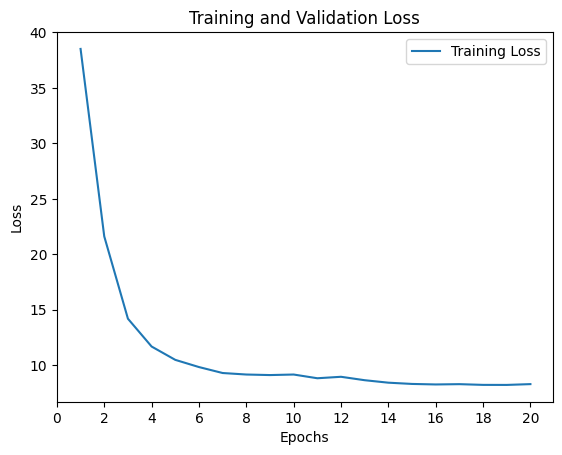

In [33]:
trainSimple_E2E(trainLoader, model, n_epochs=params["n_epochs"], learning_rate=params["lr"], criterion= params["criterion"])

Batch size is:  torch.Size([32, 10, 2])


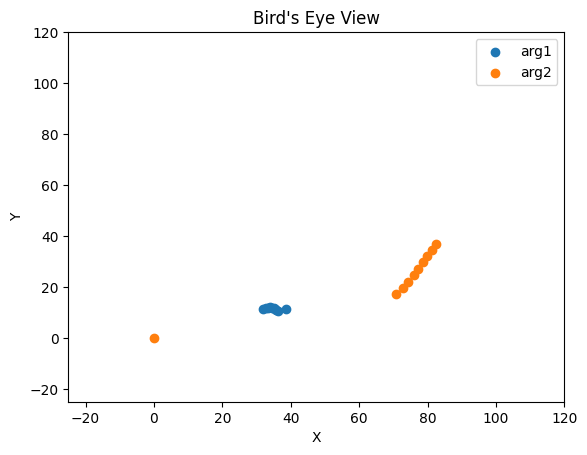

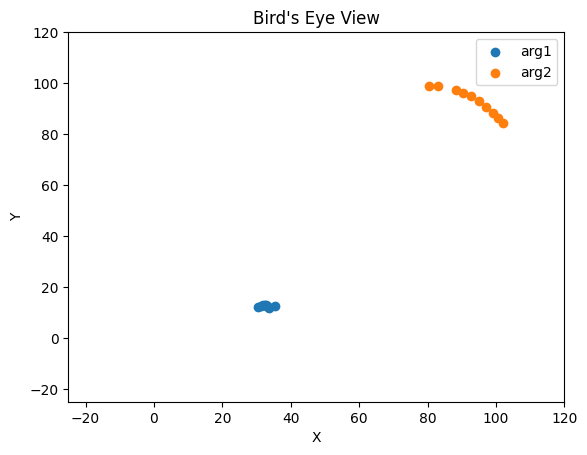

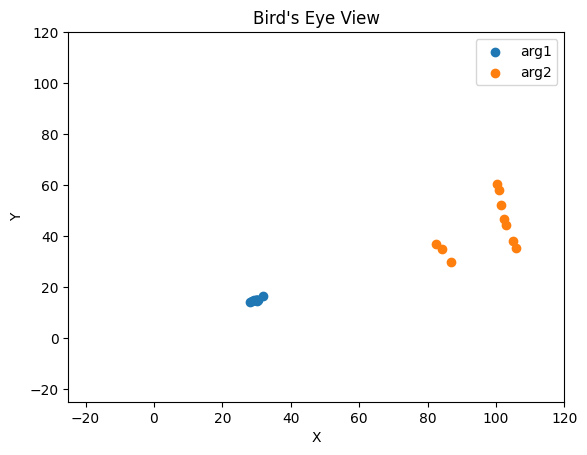

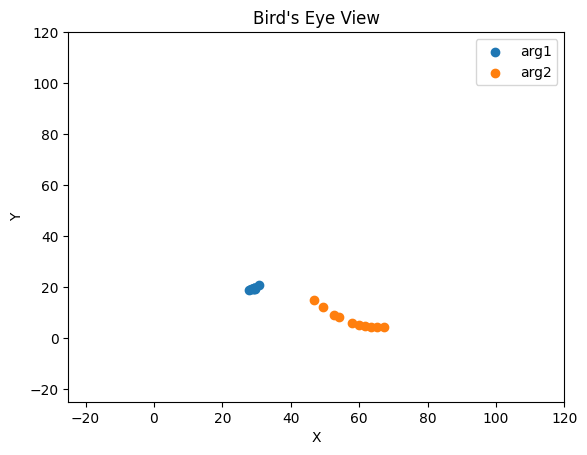

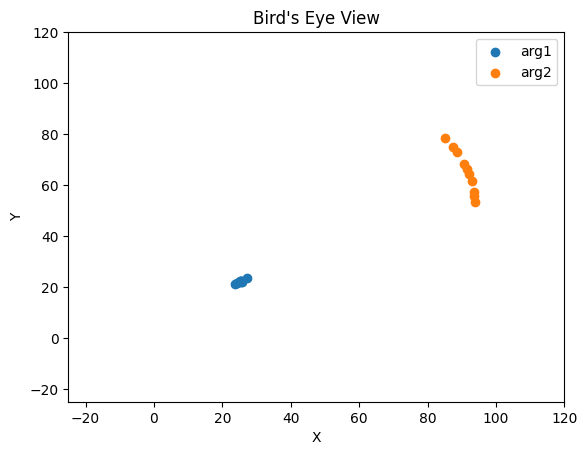

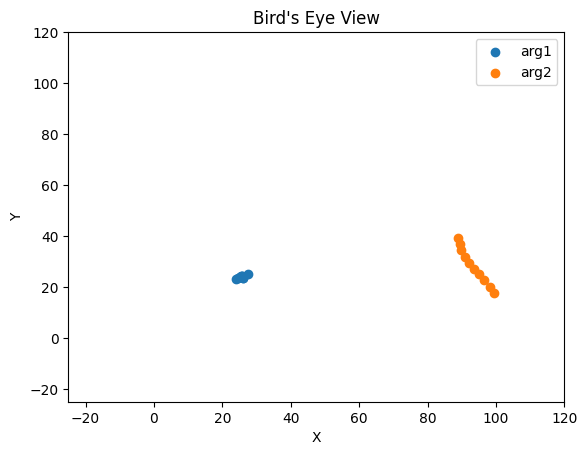

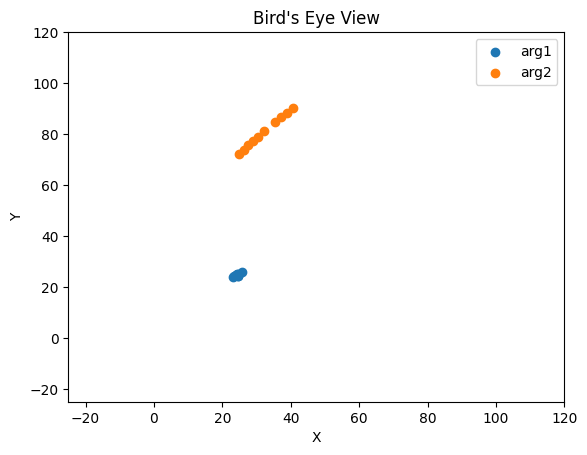

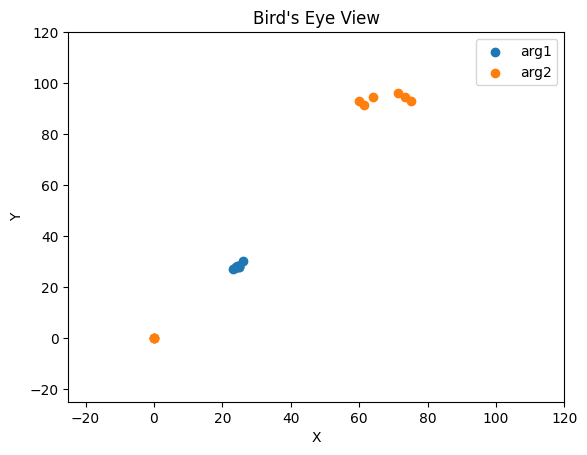

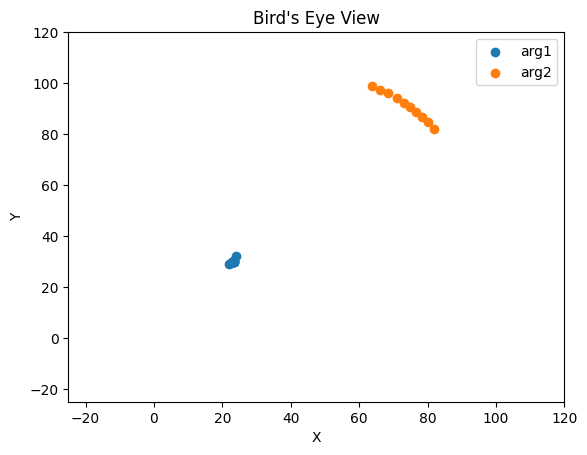

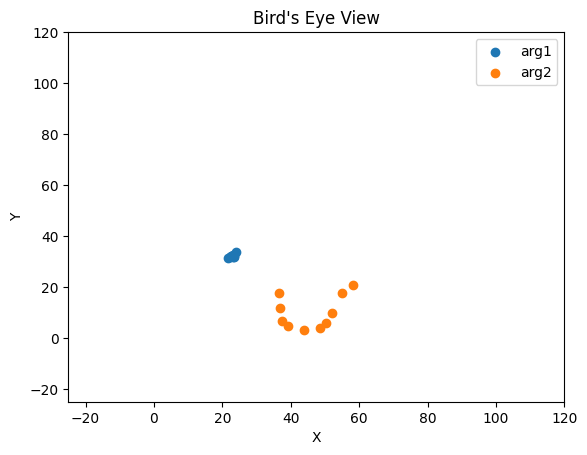

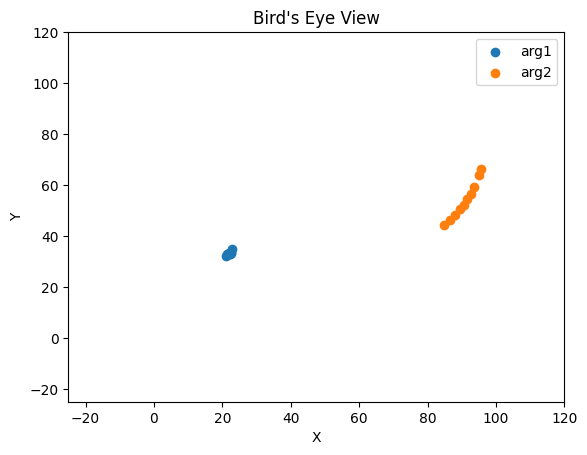

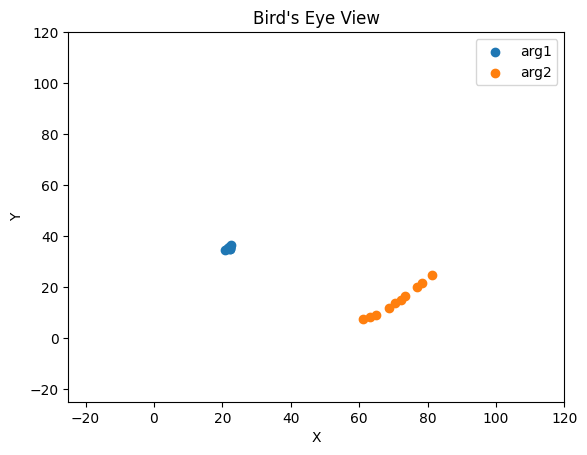

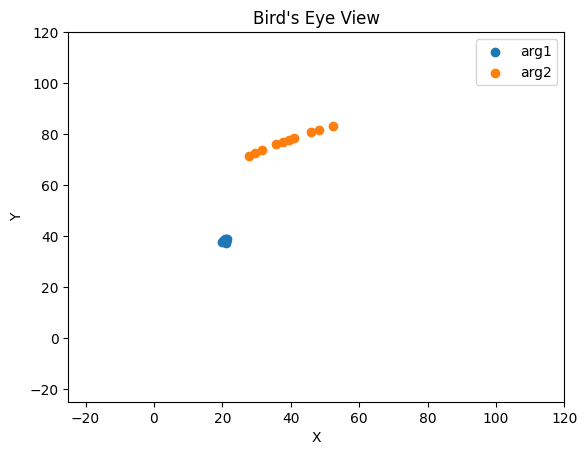

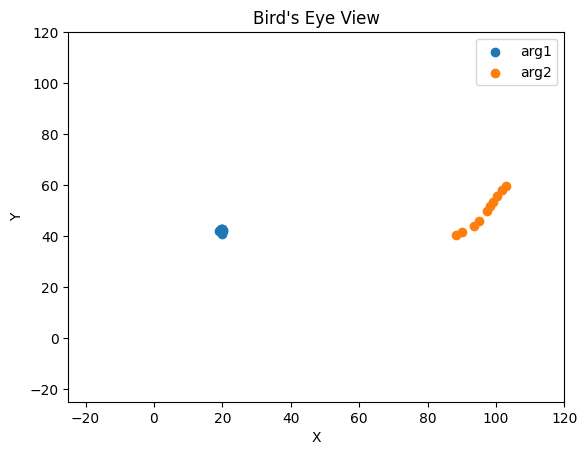

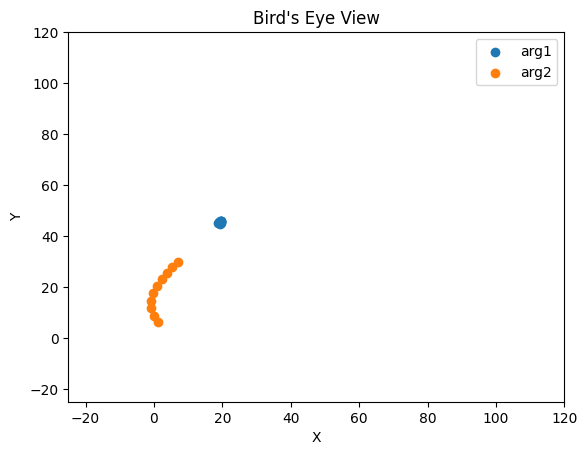

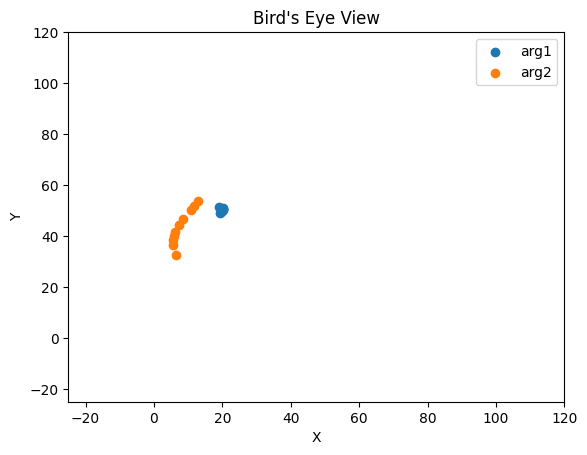

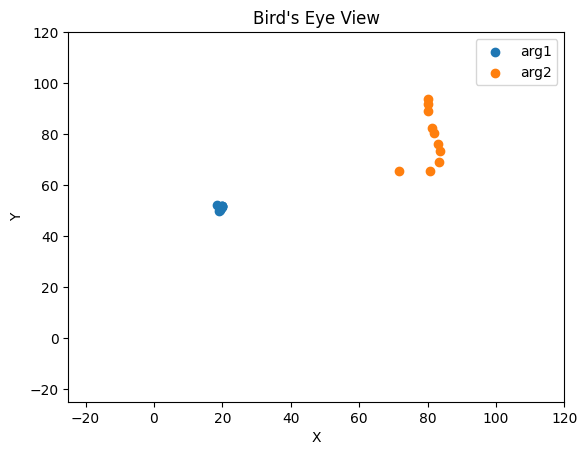

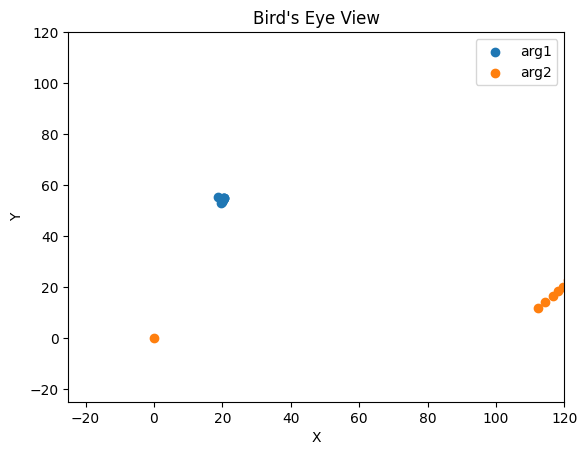

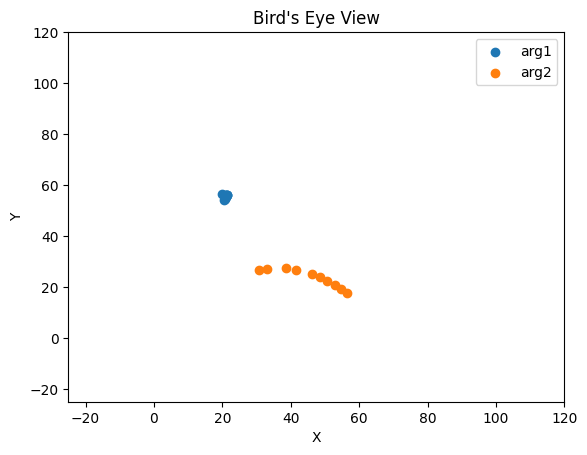

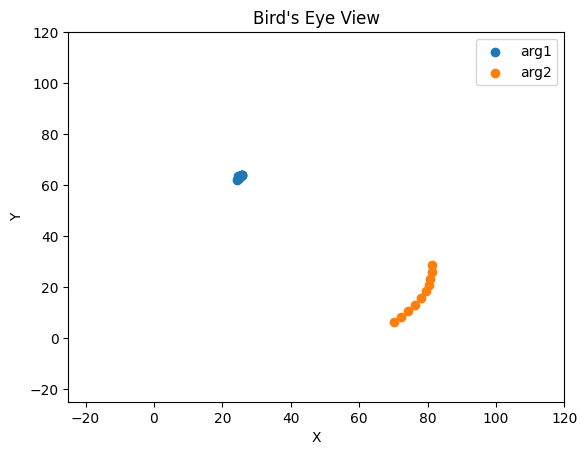

In [58]:
for i, batch in enumerate(validLoader):
    input_seq,output_sequence = batch
    print("Batch size is: ", batch[0].shape)
    for j in range (20):
        inp_ex = input_sequence[j]
        out_ex = output_sequence[j]
        with torch.no_grad():
            inp_ex.to(device)
            output_sentence = model(input_ex)
        pred = output_sentence.tolist()[0]
        target = out_ex.tolist()
        plot_points(pred, target)
        time.sleep(2)
    break

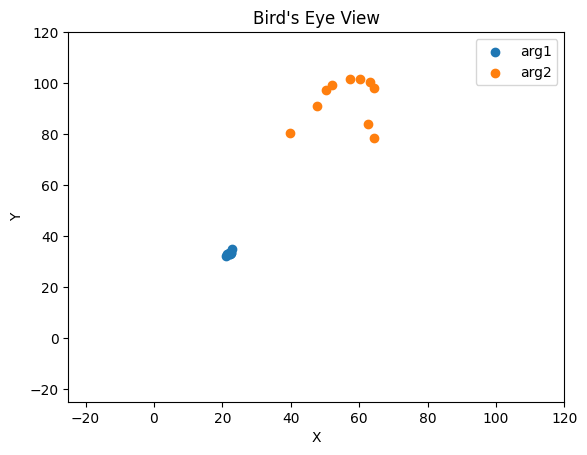

In [57]:
pred = output_sentence.tolist()[0]
target = out_ex.tolist()
plot_points(pred, target)

In [ ]:
**DECODER WITH ATTENTION**

In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # query: (batch_size, 1, hidden_size)
        # keys:  (batch_size, T, hidden_size)

        h_t = self.Wa(query) # Single decoder state (batch_size, 1, hidden_size)
        s_k = self.Ua(keys) # All encoder states (batch_size, T, hidden_size)
        # Additive att: Combine each encoder hidden state with current decoder hidden state
        scores_inp = torch.tanh(h_t + s_k) # (batch_size, T, hidden_size)
        scores = self.Va(scores_inp) # (batch_size, T, 1)
        scores = scores.squeeze(2).unsqueeze(1) # (batch_size, 1, T)

        weights = F.softmax(scores, dim=-1)  # (batch_size, 1, T)
        context = torch.bmm(weights, keys) # (batch_size, 1, hidden_size)

        return context, weights

In [33]:
class Decoder_Att(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(Decoder_Att, self).__init__()
        self.output_size = output_size
        self.attention = BahdanauAttention(hidden_size)
        self.embedding = nn.Linear(output_size, hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
    
    def forward(self, encoder_outputs, encoder_hidden):
        
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.zeros([batch_size,1,self.output_size], dtype=torch.float32, device=device)
        # decoder_input size: (batch_size, 1, output_size)
        decoder_hidden = encoder_hidden # (1, batch_size, hidden_size)

        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            # decoder_output: (batch_size, 1, output_size)
            # decoder_hidden size: (1, batch_size, hidden_size)
            # att_weights: (batch_size, 1, T)

            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            # Without teacher forcing: use its own predictions as the next input
            decoder_input = decoder_output.detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, decoder_input, decoder_hidden, encoder_outputs):
        # decoder_input size: (batch_size, 1, output_size)
        # encoder_outputs: (batch_size, T, hidden_size)
        # encoder_hidden: (1, batch_size, hidden_size)

        embedd = self.embedding(decoder_input) # (batch_size, 1, hidden_size)
        query = decoder_hidden.permute(1, 0, 2) # (batch_size, 1, hidden_size)
        context, attn_weights = self.attention(query, encoder_outputs)
        # context: (batch_size, 1, hidden_size)
        # att_weights: (batch_size, 1, T)
        input_gru = torch.cat((embedd, context), dim=2) # (batch_size, 1, 2*hidden_size)

        output, decoder_hidden  = self.gru(input_gru, decoder_hidden)
        # output size: (batch_size, 1, hidden_size)
        # decoder_hidden size: (1, batch_size, hidden_size)
        decoder_output = self.out(output) # (batch_size, 1, output_size)
        
        return decoder_output, decoder_hidden, attn_weights

class Seq2Seq_ATT(nn.Module):
    def __init__(self, input_size,hidden_size,output_size):
        super(Seq2Seq_ATT, self).__init__()
        
        self.encoder = EncoderSimple(input_size, hidden_size)
        self.decoder = Decoder_Att(hidden_size, output_size)

    def forward(self, input_tensor):
        
        encoder_outputs, encoder_hidden = self.encoder(input_tensor)
        decoder_outputs, _, _ = self.decoder(encoder_outputs, encoder_hidden)

        return decoder_outputs

In [41]:
model_att = Seq2Seq_ATT(input_size, params["hidden_size"], output_size)
model_att

Seq2Seq_ATT(
  (encoder): EncoderSimple(
    (gru): GRU(2, 128, batch_first=True)
  )
  (decoder): Decoder_Att(
    (attention): BahdanauAttention(
      (Wa): Linear(in_features=128, out_features=128, bias=True)
      (Ua): Linear(in_features=128, out_features=128, bias=True)
      (Va): Linear(in_features=128, out_features=1, bias=True)
    )
    (embedding): Linear(in_features=2, out_features=128, bias=True)
    (gru): GRU(256, 128, batch_first=True)
    (out): Linear(in_features=128, out_features=2, bias=True)
  )
)

Start training
Time: 0m 14s (- 2m 11s),  Epoch:1, Loss avg:53.0531
Time: 0m 29s (- 1m 56s),  Epoch:2, Loss avg:53.0443
Time: 0m 43s (- 1m 41s),  Epoch:3, Loss avg:53.0788
Time: 0m 58s (- 1m 27s),  Epoch:4, Loss avg:53.0594
Time: 1m 12s (- 1m 12s),  Epoch:5, Loss avg:53.0948
Time: 1m 27s (- 0m 58s),  Epoch:6, Loss avg:53.0118
Time: 1m 41s (- 0m 43s),  Epoch:7, Loss avg:53.0649
Time: 1m 56s (- 0m 29s),  Epoch:8, Loss avg:53.0400
Time: 2m 11s (- 0m 14s),  Epoch:9, Loss avg:52.9924
Time: 2m 25s (- 0m 0s),  Epoch:10, Loss avg:52.9479


<Figure size 640x480 with 0 Axes>

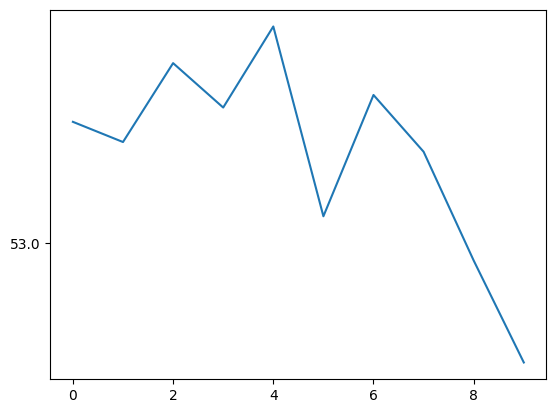

In [46]:
trainSimple_E2E(dataloader,model_att, n_epochs=params["n_epochs"], learning_rate=params["lr"], criterion= params["criterion"])

**INTRODUCING ATTENTION**

In [ ]:
class AdditiveAttention(nn.Module):
    """
     Implements the additive attention as proposed in "Neural Machine Translation by Jointly Learning to Align and Translate".
     Args:
         q_dim (int): dimesion of the queries
         k_dim (int): dimesion of the keys
         attn_dim (int): dimension of intermediate vectors

     Inputs: query, key, value
        query (torch.FloatTensor):  Query Tensor   (... x T_q x d_q)
        key (torch.FloatTensor):  Key Tensor     (... x T_k x d_k)
        value (torch.FloatTensor):  Value Tensor   (... x T_v x d_v)

    Returns:
        torch.FloatTensor: Result of the Attention Mechanism  (... x T_q x d_v)
        torch.FloatTensor: Attention map       (... x T_q x T_k)

    """
    def __init__(self, q_dim: int, k_dim: int, attn_dim: int) -> None:
        super(AdditiveAttention, self).__init__()
        
        self.proj_q = nn.Linear(q_dim, attn_dim)
        self.proj_k = nn.Linear(k_dim, attn_dim)
        
        self.bias = nn.Parameter(torch.rand(attn_dim).uniform_(-0.1, 0.1))
        self.w = nn.Linear(attn_dim, 1)

    def forward(self, query, key, value): 
        #T_q = 38 (maxL_input)
        #T_k = 56 (maxL_output)

        q_ = self.proj_q(query) # (B_S x T_q x q_dim) -> (B_s x T_q x attn_dim)
        k_ = self.proj_k(key)   # (B_s x T_k x k_dim) -> (B_s x T_k x attn_dim)

        # Prepare for Broadcasting Semantics
        q_ = q_.unsqueeze(-2)   # (B_s x T_q x attn_dim) -> (B_s x T_q x  1  x attn_dim)
        k_ = k_.unsqueeze(-3)   # (B_s x T_k x attn_dim) -> (B_s x  1  x T_k x attn_dim)

        # Sum thanks to Broadcasting Semantics
        attn_hid = torch.tanh(q_ + k_ + self.bias) # (B_s x T_q x  1  x attn_dim) + (... x  1  x T_k x attn_dim) + (attn_dim) -> (B_s x T_q x T_k x attn_dim)
        #print("att hidden: ", attn_hid.shape) # (32, 38, 56, 128)
        
        attn_logits = self.w(attn_hid)        # (B_s x T_q x T_k x attn_dim) -> (B_s x T_q x T_k x 1)
        #print("att logits size: ", attn_logits.shape) # (32, 38, 56, 1)
        attn_logits = attn_logits.squeeze(-1) # (B_s x T_q x T_k x 1) -> (B_s x T_q x T_k)
        #print("att logits size: ", attn_logits.shape) # (32, 38, 56)

        attn_weights = F.softmax(attn_logits, dim=-1) # (B_s x T_q x T_k)
        #print("att weights size: ", attn_weights.shape) # (32 x 38 x 56)

        output = torch.matmul(attn_weights, value)  # Shape: (B_s x T_q x 1 x d_v)
        output = output.squeeze(-2)                 # Shape: (B_s x T_q x d_v) = (32, 38, 256)

        return output, attn_weights

In [ ]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dropout_p = dropout_p

        # self.embedding = nn.Embedding(self.output_size, self.hidden_size)
        self.gru = nn.GRU(self.output_size, self.hidden_size, batch_first=True)
        # self.dropout = nn.Dropout(self.dropout_p)
        # Here we define the attention we use
        self.attn = AdditiveAttention(self.hidden_size, self.hidden_size, self.hidden_size // 2)
        self.attn_combine = nn.Linear(self.hidden_size * 2, self.hidden_size)
        self.out = nn.Linear(self.hidden_size, self.output_size)

    def forward(self, input, hidden, encoder_outputs):
        #T_q = 38 (maxL_input)
        #T_k = 56 (maxL_output)
        
        #print("Input size: ", input.shape) #[BS, T_q, input_size] = (32,38,2)
        #print("Hidden size: ", hidden.shape) #[1, BS, HS] = (1,32,256)
        #print("Encoder outputs size: ", encoder_outputs.shape) #[BS, T_k, HS] = (32, 56, 256)
        # embedded = self.embedding(input)
        # embedded = self.dropout(embedded)
        x, hidden = self.gru(input)
        #print("x size: ", x.shape) #[BS, T_q, HS] = (32,38,256)
        #print("hidden size: ", hidden.shape) #[1,BS,HS] = (1, 32, 256)
        context, attn_weights = self.attn(query=x, key=encoder_outputs, value=encoder_outputs)
        #print("context size: ", context.shape) # [BS, T_q, HS] = (32, 38, 256)
        #print("attn_weights size: ", hidden.shape) # [1,BS,HS] = (1, 32, 256)
        x_w_context = torch.cat((x, context), dim=-1)  # Shape: (BS, T_q, HS * 2) = (32,38,256*2)
        x_w_context = self.attn_combine(x_w_context)  # Shape: (BS, T_q, HS) = (32,38,256)
        
        output = F.log_softmax(self.out(x_w_context), dim=-1)  # Shape: (BS, T_q, output_size) = (32,38,2)
        return output, hidden, attn_weights

In [ ]:
attn_decoder1 = AttnDecoderRNN(hidden_size, output_size, dropout_p=0.1).to(device)
attn_decoder1

In [ ]:
def train(input_tensor, target_tensor, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    
    encoder_outputs, encoder_hidden = encoder(input_tensor)
    
    # First hidden state used by the decoder is the last encoder hidden state
    decoder_hidden = encoder_hidden
    # Use car positions as decoder input # decoder_input = input_tensor[:,0,:].unsqueeze(1)
    decoder_input = target_tensor

    #print("Decoder input size: ", decoder_input.shape) #[BS, 38, 2]
    #print("Decoder hidden size: ", encoder_hidden.shape) #[1, BS, HS]
    #print("Encoder outputs size: ", encoder_outputs.shape) #[BS, 56, HS]
    
    decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)
    #print("Decoder output shape: ", decoder_output.shape)
    #print("Target shape :", target_tensor.shape)
    loss = criterion(
        decoder_output,
        target_tensor
    )
    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_tensor.numel(), decoder_output, target_tensor

In [ ]:
def trainIters(dataloader, encoder, decoder, n_epochs=2, learning_rate=0.01):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every epoch
    plot_loss_total = 0  # Reset every epoch

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    criterion = nn.MSELoss()
    
    print("Start training")
    for epoch in range(1,n_epochs+1):        
        for input_seq, target_seq in dataloader:
            input_seq.requires_grad=True
            loss, dec_out, tt = train(input_seq, target_seq, encoder,
                        decoder, encoder_optimizer, decoder_optimizer, criterion)
            print_loss_total += loss
            plot_loss_total += loss
            
            if math.isnan(loss):
                print("Loss item: ", loss)
                return dec_out,tt, input_seq

        print_loss_avg = print_loss_total
        print('Time: %s,  Epoch:%d, Current state:%d%%, Loss avg:%.4f' % (timeSince(start, epoch / n_epochs),
                                     epoch, epoch / n_epochs * 100, print_loss_avg))
        print_loss_total = 0

        plot_loss_avg = plot_loss_total
        plot_losses.append(plot_loss_avg)
        plot_loss_total = 0

    showPlot(plot_losses)
    return 0,0